### Non-linear (power-law) scaling
Edit the `👈` value and re-run.

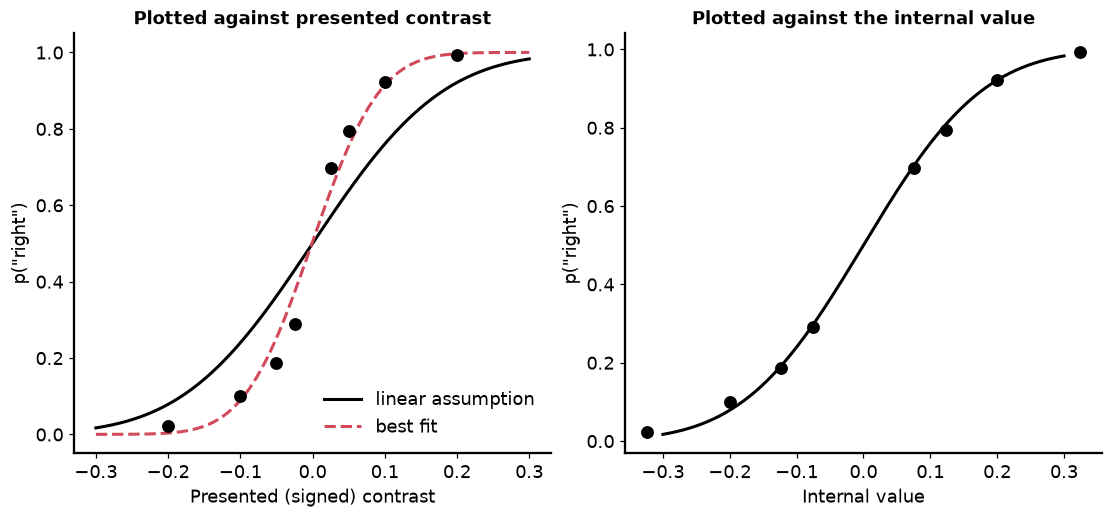

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 12, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})

def neg_log_lik(p, pf, x, n_right, n_total):
    pp = np.clip(pf(p, x), 1e-6, 1 - 1e-6)
    return -np.sum(n_right * np.log(pp) + (n_total - n_right) * np.log(1 - pp))

def probit(p, x):            # p = [mean, sd]
    return norm.cdf(x, p[0], p[1])

# perceived contrast follows a power law of presented contrast
signal_strengths = np.array([0.025, 0.05, 0.1, 0.2])
internal = signal_strengths ** 0.7        # 👈 try other exponents
noise_sd = 0.1
ntrials  = 1000
rng = np.random.default_rng(); half = ntrials // 2

left  = rng.standard_normal((ntrials, signal_strengths.size)) * noise_sd
right = rng.standard_normal((ntrials, signal_strengths.size)) * noise_sd
left[:half]  += internal      # internal (perceived) value is added, not presented
right[half:] += internal
resp_right = (right - left) > 0
p_left  = resp_right[:half].mean(axis=0)
p_right = resp_right[half:].mean(axis=0)

# fit a probit against the PRESENTED contrast
x  = np.concatenate([-signal_strengths, signal_strengths])
pr = np.concatenate([p_left, p_right])
fit = minimize(lambda p: neg_log_lik(p, probit, x, pr*half, np.full(x.size, half)),
               x0=[0, noise_sd], method="Nelder-Mead").x

xs = np.linspace(-0.3, 0.3, 200)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 4.6), constrained_layout=True)
axL.scatter(-signal_strengths, p_left, 55, color="k", zorder=3)
axL.scatter(signal_strengths, p_right, 55, color="k", zorder=3)
axL.plot(xs, norm.cdf(xs, 0, noise_sd*np.sqrt(2)), "k", lw=2, label="linear assumption")
axL.plot(xs, probit(fit, xs), color="#d1495b", ls="--", lw=2, label="best fit")
axL.set(xlabel="Presented (signed) contrast", ylabel='p("right")', title="Plotted against presented contrast")
axL.legend(loc="lower right")

axR.scatter(-internal, p_left, 55, color="k", zorder=3)
axR.scatter(internal, p_right, 55, color="k", zorder=3)
axR.plot(xs, norm.cdf(xs, 0, noise_sd*np.sqrt(2)), "k", lw=2)
axR.set(xlabel="Internal value", ylabel='p("right")', title="Plotted against the internal value")
plt.show()
